# **Anova Case Study**

This notebook presents a One-Way ANOVA (Analysis of Variance) case study to test whether the average values across multiple groups are significantly different.

**One Way Anova**

---

Here the 'One Way' refers to the fact there's only one independent variable (factor) with multiple levels(groups) in the analysis.

We have a titatic dataset , in which we have two columns named -
* p_class - Representing the class in which passegers are travelling
* Age - Age of the passenger

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chisquare

df= pd.read_csv('/content/train (1).csv').dropna()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S


**Problem Statement**


---


Is the average age of passengers the same across all passenger classes in the Titanic dataset?

Feature used:

- Pclass — Passenger class (1, 2, or 3)
- Age — Age of passenger

Here:

- Pclass is the independent variable (factor)
- Age is the dependent variable (response)

Since one factor (Pclass) has multiple groups, One-Way ANOVA is an appropriate method.

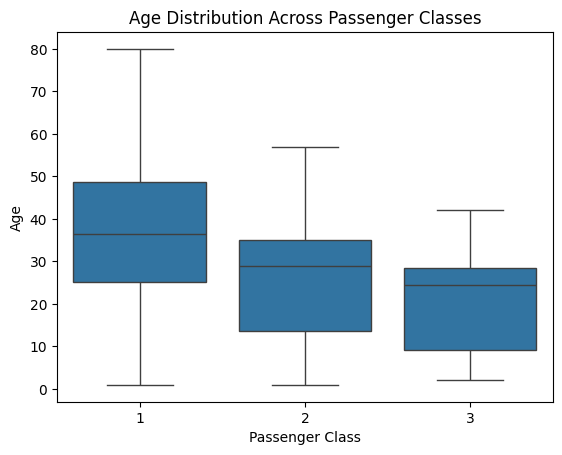

In [5]:
#Boxplots for Age Across Classes
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Pclass', y='Age', data=df)

plt.title('Age Distribution Across Passenger Classes')
plt.xlabel('Passenger Class')
plt.ylabel('Age')

plt.show()

- Different median lines suggest different average ages.
- No outlier

**The goal is to test whether:**

Mean age in Class 1 = Mean age in Class 2 = Mean age in Class 3

or

At least one class has a different average age.

**Assumptions**

---

1. Variances of all groups should be roughly equal. Levene’s test checks this.


In [6]:
# Null Hypothesis (H₀): Group variances are equal
# Alternative (H₁): Variances are different

from scipy.stats import levene

group1 = df[df['Pclass']==1]['Age']
group2 = df[df['Pclass']==2]['Age']
group3 = df[df['Pclass']==3]['Age']

stat, p = levene(group1, group2, group3)

print("Levene Statistic:", stat)
print("P-value:", p)

Levene Statistic: 0.2809810296154258
P-value: 0.7553732149818655


p-value > 0.05 (Significance level) ---> Equal variance assumption holds.

2. ANOVA assumes data in each group is approximately normal. Shapiro-Wilk checks this.

In [7]:
from scipy.stats import shapiro

for cls in df['Pclass'].unique():

    stat, p = shapiro(
        df[df['Pclass']==cls]['Age']
    )

    print(f"Pclass {cls}")
    print("Statistic:", stat)
    print("P-value:", p)

Pclass 1
Statistic: 0.9913494912447626
P-value: 0.4537540151313615
Pclass 3
Statistic: 0.9275473047705957
P-value: 0.42420546955563504
Pclass 2
Statistic: 0.888080595207842
P-value: 0.06272790951416782


p-value > 0.05 --> Data is approximately normal.

**Hypothesis Testing**

- Null Hypothesis (H0) : All group means are equal. μ1 = μ2 = μ3
Passenger age does not vary by class.
- Alternative Hypothesis (H1) : At least one group mean is different.
This means age distribution may vary across classes.

In [2]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model =ols('Age ~ Pclass', data = df).fit()

anova_result = sm.stats.anova_lm(model, type=2)
print(anova_result)

             df        sum_sq      mean_sq          F    PR(>F)
Pclass      1.0   4184.667258  4184.667258  18.768443  0.000024
Residual  181.0  40356.291456   222.962936        NaN       NaN


**F-Statistic**

F = 18.768

The F-statistic compares:

- Variability between groups vs
- Variability within groups

A large F-value suggests group means are not all equal.

**P-Value**

P-value = 0.000024

Since:
0.000024 < 0.05

We reject the null hypothesis.

**Conclusion from ANOVA**

---
There is a statistically significant difference in mean passenger age across travel classes.

This tells us:

- All classes do not have the same average age.
- At least one class differs.

However, ANOVA does not tell us which classes differ.

That is why Post-Hoc tests are performed next.

## **Post-Hoc Test**



**Why Post-Hoc Tests?**

ANOVA detects whether a difference exists overall.

Post-Hoc tests identify:

- Which group pairs are significantly different
- Which pairs are not significantly different

Two approaches are used in the notebook:



1.   Bonferroni pairwise t-tests
2.   Tukey's HSD test



  **Bonferroni pairwise t-tests**

  ---

In [3]:
import scipy.stats as stats

for class1,class2 in [(1,2),(2,3),(3,1)]: #We have every possible combination
  print(class1,class2)
  print(stats.ttest_ind(df[df['Pclass']== class1]['Age'], df[df['Pclass'] == class2]['Age']))  #Applying T-test

1 2
TtestResult(statistic=np.float64(3.035548215217273), pvalue=np.float64(0.002776567400486179), df=np.float64(171.0))
2 3
TtestResult(statistic=np.float64(0.6926446255577782), pvalue=np.float64(0.49546732037117347), df=np.float64(23.0))
3 1
TtestResult(statistic=np.float64(-3.4307649395646544), pvalue=np.float64(0.0007595353757228983), df=np.float64(166.0))


The notebook compares all possible class pairs:

(1,2)
(2,3)
(3,1)

using: stats.ttest_ind()

**Results**

---

- Class 1 vs Class 2 ---> p = 0.002776

Significant difference exists. Average ages differ between Class 1 and Class 2.


- Class 2 vs Class 3 ---> p = 0.495467

Not significant. Average ages are statistically similar.

- Class 3 vs Class 1 ---> p = 0.000759

Significant difference exists. Average ages differ between Class 3 and Class 1.

> This suggests Class 1 is mainly driving the ANOVA significance.

**Tukey's HSD (Honestly Significant disfference) Test**

---

,0,1,2,3,4,5,6
0,group1,group2,meandiff,p-adj,lower,upper,reject
1,1,2,-12.3246,0.0073,-21.8645,-2.7847,True
2,1,3,-16.5913,0.0023,-28.1051,-5.0775,True
3,2,3,-4.2667,0.7641,-18.6818,10.1484,False


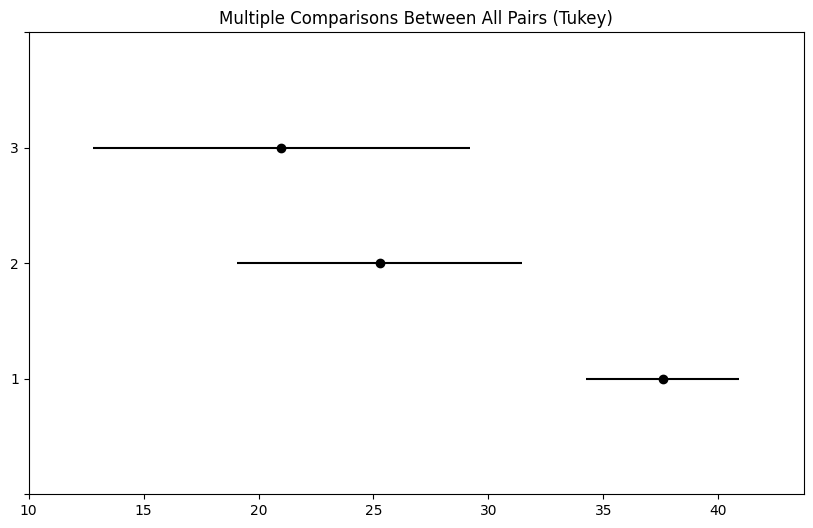

In [4]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

tukey = pairwise_tukeyhsd(endog = df['Age'], groups=df['Pclass'], alpha = 0.05)

tukey.plot_simultaneous()

plt.vlines(x=49.57,ymin=-0.5,ymax=4.5, color='red')

pd.DataFrame(tukey.summary())

**Interpretation**

Class 1 vs Class 2
- Mean difference = -12.32
- Significant
- Reject null
- Passengers in these classes have different average ages.

Class 1 vs Class 3
- Mean difference = -16.59
- Significant
- Reject null
- Strong evidence of age difference.

Class 2 vs Class 3
- Mean difference = -4.27
- Not significant
- Fail to reject null
- Average ages are similar.

The notebook uses:

tukey.plot_simultaneous()

This produces confidence interval plots for pairwise mean differences.

How to read it:

- If intervals cross zero → difference may not be significant
- If intervals do not cross zero → significant difference likely exists

**Final Findings**

---

The analysis shows:

- Passenger age differs across classes overall.
- Class 1 differs significantly from both Class 2 and Class 3.
- Class 2 and Class 3 do not differ significantly.
- The overall ANOVA significance is mainly driven by Class 1.

Passenger age is not the same across all Titanic travel classes.

Specifically:

- Class 1 passengers have significantly different average ages compared with Class 2 and Class 3.
- Class 2 and Class 3 show no significant age difference.

Therefore, passenger class appears associated with differences in age.